# Phase 3 — time-aware forecasting models
Models are tuned on expanding training-date folds and selected on validation. Test data never selects the model or its parameters. One-day and recursive scores answer different questions.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
root = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'config/config.yaml').is_file())
sys.path.insert(0, str(root))
from src.utils.config import load_config, resolve_path
config = load_config()
print('Python:', sys.executable)
metrics = json.loads(resolve_path(config, 'metrics').read_text())
print('Validation-selected:', metrics['selected_point_model'])
print('Relative one-day WAPE improvement:', metrics['relative_wape_improvement'])
print('Requested improvement achieved:', metrics['meets_requested_improvement'])
display(pd.DataFrame(metrics['one_day_test_metrics']))
display(pd.read_csv(resolve_path(config, 'model_recursive_metrics')))

Python: C:\Users\aamit\OneDrive\Desktop\ProjectX\coffee-inventory-ml\.venv\Scripts\python.exe
Validation-selected: lightgbm
Relative one-day WAPE improvement: 0.2564589063135738
Requested improvement achieved: True


,model,item,rows,wape,mae,rmse,bias,interval_coverage,mean_interval_width
0,ridge,overall,1593,0.206727,11.118491,14.642547,-0.706204,NaN,NaN
1,lightgbm,overall,1593,0.214928,11.559544,15.548872,-2.186109,NaN,NaN
2,naive,overall,1593,0.294029,15.813894,20.890915,-0.160912,NaN,NaN
3,seasonal_naive,overall,1593,0.289059,15.546610,20.704408,-0.316604,NaN,NaN
4,moving_average,overall,1593,0.232385,12.498446,16.406701,-0.293451,NaN,NaN
5,quantile_p50,overall,1593,0.219289,11.794100,15.966127,-3.282890,0.740741,32.89391


,model,horizon_day,rows,wape,mae,rmse,bias,interval_coverage,mean_interval_width
0,lightgbm,1,224,0.202351,12.441850,16.986129,-2.854670,0.781250,37.081063
1,lightgbm,2,218,0.250307,11.983721,16.403030,-2.181957,0.674312,30.663778
2,lightgbm,3,224,0.216678,10.911284,14.769252,-2.999969,0.767857,31.255329
3,lightgbm,4,219,0.207723,10.444959,13.805773,-1.289774,0.767123,31.496523
4,lightgbm,5,224,0.236655,11.636234,15.732398,-0.353391,0.714286,30.226994
5,lightgbm,6,222,0.199371,11.146836,14.282815,-3.835744,0.743243,33.825822
6,lightgbm,7,223,0.202976,11.849063,15.420144,-0.490786,0.798206,37.673592
7,seasonal_naive,1,224,0.297735,18.306696,24.848633,0.122173,NaN,NaN
8,seasonal_naive,2,218,0.304682,14.587003,19.339801,-0.103823,NaN,NaN
9,seasonal_naive,3,224,0.274447,13.820387,17.755564,-0.112649,NaN,NaN


## Comparison, empirical intervals and LightGBM SHAP
The nominal 80% band undercovers the measured test targets. Tree SHAP describes fitted-model associations, not causal weather or promotion effects.

comparison


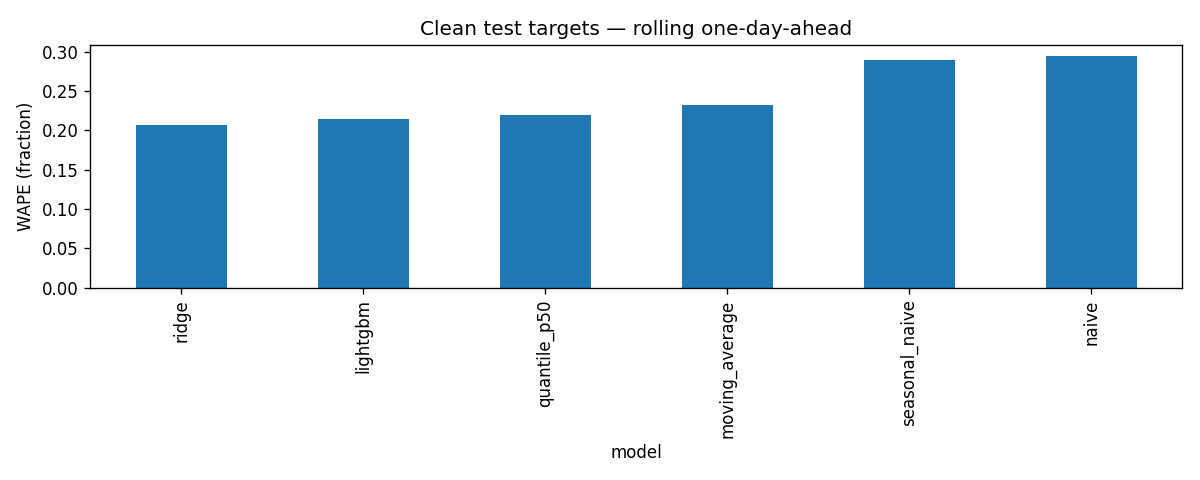

intervals


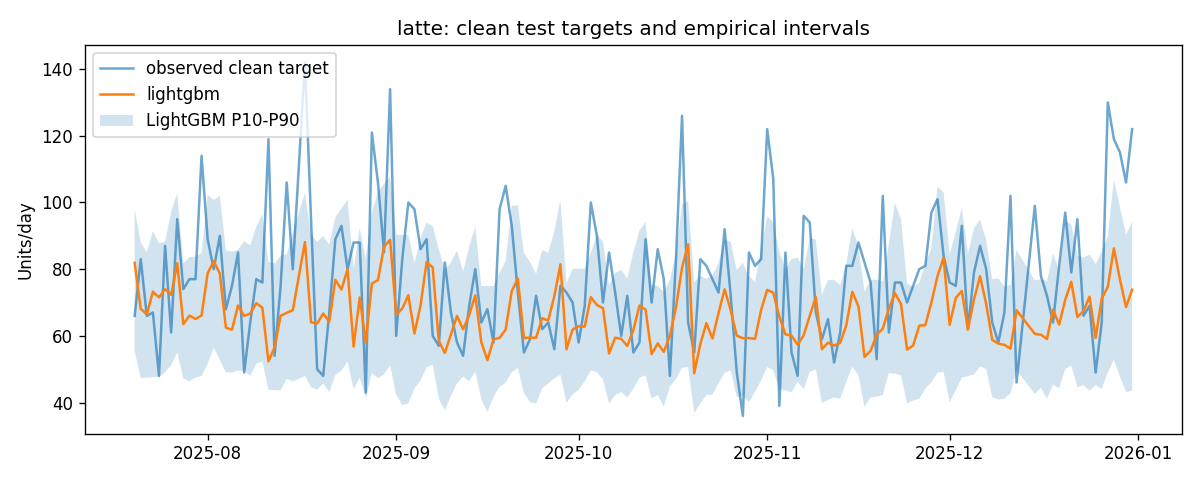

shap


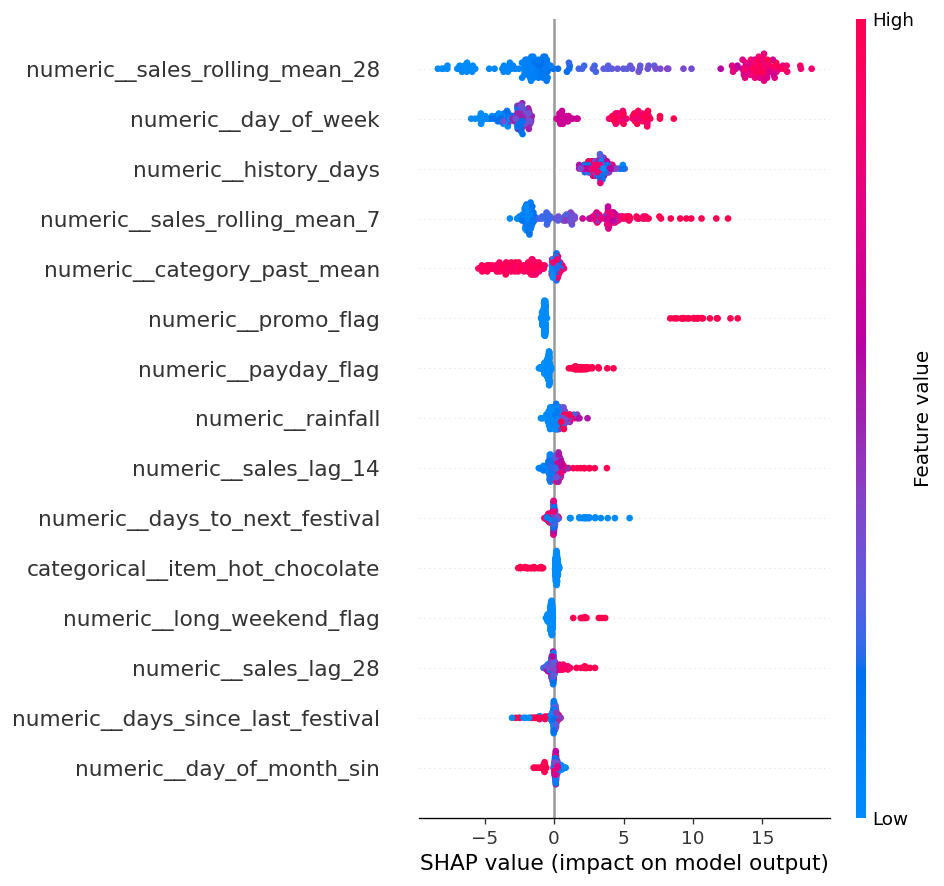

In [2]:
from IPython.display import Image, display
for name, filename in config['model_figures'].items():
    print(name)
    display(Image(filename=str(resolve_path(config, 'figures') / filename)))

## Saved model, seven-day demo and top drivers
The saved bundle was trained through validation end, before the first test demo origin. Unknown future lags are filled recursively with predictions, not actual future sales.

In [3]:
from src.models.predict import load_artifact, recursive_forecast
from src.data.loader import load_sales
from src.utils.dates import get_as_of_date
artifact = load_artifact(config)
print('Trained through:', artifact['trained_through'])
display(pd.read_csv(resolve_path(config, 'demo_forecast')).head(20))
print(resolve_path(config, 'model_explanation').read_text())

Trained through: 2025-07-19


,date,item,forecast,p10,p50,p90,origin,horizon_day,quantile_crossed
0,2025-07-20,americano,54.259332,32.502423,47.750537,74.867217,2025-07-20,1,False
1,2025-07-20,cappuccino,78.902393,51.298420,71.755767,96.646275,2025-07-20,1,False
2,2025-07-20,cold_coffee,59.972835,41.548705,55.172060,82.555459,2025-07-20,1,False
3,2025-07-20,croissant,39.519240,27.342088,38.821689,51.466154,2025-07-20,1,False
4,2025-07-20,espresso,76.577356,49.283833,68.123663,98.952286,2025-07-20,1,False
5,2025-07-20,hot_chocolate,38.780446,27.222529,37.547551,50.898416,2025-07-20,1,False
6,2025-07-20,iced_latte,43.450548,31.323193,40.492906,58.316701,2025-07-20,1,False
7,2025-07-20,latte,81.916383,55.401084,81.877174,97.940743,2025-07-20,1,False
8,2025-07-20,masala_chai,78.488660,52.744052,73.634880,103.168453,2025-07-20,1,False
9,2025-07-20,sandwich,44.300154,27.991992,41.101832,61.012979,2025-07-20,1,False


{
  "forecast": 54.259332412705426,
  "raw_model_estimate": 54.259332412705504,
  "reference": 43.06334383438392,
  "method": "additive SHAP association; not causal",
  "drivers": [
    {
      "feature": "day_of_week",
      "contribution": 4.846111471980016,
      "explanation": "day of week raised the model estimate by 4.85 units relative to its reference."
    },
    {
      "feature": "history_days",
      "contribution": 3.816796964157435,
      "explanation": "history days raised the model estimate by 3.82 units relative to its reference."
    },
    {
      "feature": "rainfall",
      "contribution": 1.1637398913209247,
      "explanation": "Forecast rainfall raised the model estimate by 1.16 units relative to its reference."
    },
    {
      "feature": "sales_rolling_mean_7",
      "contribution": 0.7804259705655955,
      "explanation": "sales rolling mean 7 raised the model estimate by 0.78 units relative to its reference."
    },
    {
      "feature": "promo_flag",
    

## Fixed-origin leakage check
Mutating future actual sales and realized weather cannot change the forecast. Only calendar and known planned promotion/price may affect future predictions.

In [4]:
sales = load_sales(config)
origin = get_as_of_date(config)
end = origin + pd.Timedelta(days=config['project']['forecast_horizon_days']-1)
history = sales.loc[sales.date.lt(origin)]
plans = sales.loc[sales.date.between(origin, end)].copy()
first = recursive_forecast(artifact, history, plans, origin, config)
plans[['sales','temp_max','temp_min','rainfall']] = [999999,999,998,999]
plans['record_status'] = 'outlier'
second = recursive_forecast(artifact, history, plans, origin, config)
pd.testing.assert_frame_equal(first, second)
print('Fixed-origin future sales/weather mutation: PASS')
assert pd.Timestamp(artifact['trained_through']) < origin
print('Training cutoff before demo origin: PASS')

Fixed-origin future sales/weather mutation: PASS
Training cutoff before demo origin: PASS


## Interpretation and next steps
Ridge scored better than the validation-selected LightGBM on this test split; deployment choice stays frozen. Forecast uncertainty is empirical and undercalibrated. Cold-start predictions use category history. Inventory economics and policy benefits remain unmeasured until later phases.